# MVP v0.3.2.5 -- Negative Guidance Sweep

**Builds on:** v0.2.5.14d (positive guidance, rho=0.886 at alpha=0.4)

**Goal:** Implement negative guidance using BCGaussian behavior policy. Fix positive
guidance alpha=0.3, sweep negative guidance ratio in [0.0, 0.1, 0.3, 0.5, 0.7, 1.0].

Formula: 

**Behavior policy:** 
(BCGaussian trained on same 200 demos + 50 rollouts as chunk diffuser)

In [1]:
%matplotlib inline
import sys, os, importlib
import numpy as np
import torch
import torch.nn as nn
import h5py, json, math, time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_BASE = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models"
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
BEHAVIOR_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0214_fixed_guidance"
ORACLE_JSON = PROJECT_ROOT / "results/2026-03-12/oracle_eval_all_checkpoints.json"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = 26
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0
NUM_SYNTHETIC = 50
T_GEN = 60
GAMMA = 1.0
SCORE_TIMESTEP = 5
SIGMOID_SHARPNESS = 150.0

# Guidance config -- fixed positive, sweep negative
ALPHA = 0.3   # fixed at optimal from v0.2.5.14d
LAMBDAS = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]

TARGET_POLICIES = [
    {"name": "10demos_epoch10", "dir": "lift_diffusion_10demos/20260311115828", "ckpt": "models/model_epoch_10.pth"},
    {"name": "100demos_epoch20", "dir": "lift_diffusion_100demos/20260311135551", "ckpt": "models/model_epoch_20.pth"},
    {"name": "test_checkpoint", "dir": "test/20260309132349", "ckpt": "last.pth"},
    {"name": "10demos_epoch30", "dir": "lift_diffusion_10demos/20260311115828", "ckpt": "models/model_epoch_30.pth"},
    {"name": "50demos_epoch30", "dir": "lift_diffusion_50demos/20260311134204", "ckpt": "models/model_epoch_30.pth"},
    {"name": "200demos_epoch40", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_40.pth"},
]

print(f"Positive alpha: {ALPHA} (fixed)")
print(f"Negative ratio sweep: {LAMBDAS}")
print(f"{len(TARGET_POLICIES)} policies x {len(LAMBDAS)} ratios = {len(TARGET_POLICIES)*len(LAMBDAS)} guided runs")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
Positive alpha: 0.3 (fixed)
Negative ratio sweep: [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
6 policies x 6 ratios = 36 guided runs


In [2]:
# ── Reward + OPE functions ──
def hard_reward(cube_z):
    return (cube_z > LIFT_THRESHOLD).astype(np.float32)

def sigmoid_reward(cube_z, center=LIFT_THRESHOLD, sharpness=SIGMOID_SHARPNESS):
    return (1.0 / (1.0 + np.exp(-sharpness * (cube_z - center)))).astype(np.float32)

def compute_ope_hard(states, gamma=1.0):
    cube_z = states[:, :, CUBE_Z_INDEX]
    return (hard_reward(cube_z) * (gamma ** np.arange(states.shape[1]))[None, :]).sum(axis=1)

def compute_ope_sigmoid(states, gamma=1.0):
    cube_z = states[:, :, CUBE_Z_INDEX]
    return (sigmoid_reward(cube_z) * (gamma ** np.arange(states.shape[1]))[None, :]).sum(axis=1)

def compute_sr_hard(states):
    cube_z = states[:, :, CUBE_Z_INDEX]
    return np.mean([np.any(cube_z[j] > LIFT_THRESHOLD) for j in range(states.shape[0])])

print("Functions defined.")

Functions defined.


In [3]:
# ── Load oracle ──
with open(ORACLE_JSON, "r") as f:
    oracle_all = json.load(f)

oracle_sr_map = {}
for pol in TARGET_POLICIES:
    name = pol["name"]
    if name == "test_checkpoint":
        with open(CKPT_BASE / "test/20260309132349/oracle_50.json", "r") as f:
            test_oracle = json.load(f)
        oracle_sr_map[name] = float(test_oracle["mean_return"])
    else:
        oracle_sr_map[name] = float(oracle_all[name]["mean_return"])

print("Oracle SR:")
for name, sr in sorted(oracle_sr_map.items(), key=lambda x: x[1]):
    print(f"  {name:<22} {sr*100:>5.0f}%")

Oracle SR:
  10demos_epoch10            8%
  100demos_epoch20          42%
  test_checkpoint           54%
  10demos_epoch30           62%
  50demos_epoch30           82%
  200demos_epoch40          90%


In [4]:
# ── Load data + normalization + diffuser ──
all_states_list, all_actions_list = [], []
target_data = []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    actions = actions.astype(np.float32)
    target_data.append({"states": states, "actions": actions})
    all_states_list.append(states)
    all_actions_list.append(actions)

with h5py.File(DEMO_HDF5, "r") as f:
    for dk in sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1])):
        demo = f[f"data/{dk}"]
        states = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS], axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        all_states_list.append(states)
        all_actions_list.append(actions)

all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

initial_states_t = torch.tensor(
    np.array([ep["states"][0] for ep in target_data[:NUM_SYNTHETIC]]),
    dtype=torch.float32, device=device
)

temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)
ema = EMA(diffusion_model)
ema.ema_model.load_state_dict(
    torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
)
print(f"Loaded diffuser. Initial states: {initial_states_t.shape}")

[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Loaded diffuser. Initial states: torch.Size([50, 19])


In [5]:
# ── Load BCGaussian behavior policy ──
class BCGaussian(nn.Module):
    """Simple BC policy with Gaussian output for SOPE-style guidance."""
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, action_dim)
        self.log_std_head = nn.Linear(hidden_dim, action_dim)

    def forward(self, state):
        h = self.net(state)
        return self.mean_head(h), self.log_std_head(h).clamp(-5, 2)

    def log_prob(self, state, action):
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        return -0.5 * (((action - mean) / std) ** 2 + 2 * log_std + math.log(2 * math.pi)).sum(dim=-1)

    def grad_log_prob(self, state, action):
        """Analytic gradient: -(a - mu) / sigma^2."""
        with torch.no_grad():
            mean, log_std = self.forward(state)
            std = torch.exp(log_std)
            return -(action - mean) / (std ** 2)

    def grad_log_prob_chunk(self, states, actions):
        B, T, _ = states.shape
        return self.grad_log_prob(
            states.reshape(B * T, -1), actions.reshape(B * T, -1)
        ).reshape(B, T, -1)

behavior_policy = BCGaussian(STATE_DIM, ACTION_DIM, hidden_dim=256).to(device)
behavior_policy.load_state_dict(
    torch.load(BEHAVIOR_SAVE_DIR / "bc_behavior.pt", map_location=device)
)
behavior_policy.eval()

# Sanity check
test_s = initial_states_t[:4]
test_a = torch.randn(4, ACTION_DIM, device=device)
test_grad = behavior_policy.grad_log_prob(test_s, test_a)
print(f"Behavior policy loaded. Test grad shape: {test_grad.shape}, magnitude: {test_grad.abs().mean():.4f}")

Behavior policy loaded. Test grad shape: torch.Size([4, 7]), magnitude: 400.6733


In [6]:
# ── Build paired real trajectory array for state-based logRMSE ──
real_states_list = []
for ep in target_data[:NUM_SYNTHETIC]:
    s = ep["states"]
    T = len(s)
    if T >= T_GEN:
        real_states_list.append(s[:T_GEN])
    else:
        padded = np.zeros((T_GEN, STATE_DIM), dtype=np.float32)
        padded[:T] = s
        padded[T:] = s[-1]
        real_states_list.append(padded)
real_states = np.array(real_states_list)
print(f"Real states for comparison: {real_states.shape}")

Real states for comparison: (50, 60, 19)


In [7]:
# ── Trajectory generator (positive + negative guidance) ──
def generate_trajectories(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen, device,
    target_scorer=None, behavior_scorer=None,
    alpha=0.0, lam=0.0, normalize_grad=True,
):
    """
    SOPE-style guided trajectory generation.
    guide = target_grad - lam * behavior_grad
    Applied to action dimensions only, scaled by alpha.
    """
    use_pos = (target_scorer is not None and alpha > 0)
    use_neg = (behavior_scorer is not None and lam > 0)
    guided = use_pos or use_neg
    B = initial_states.shape[0]
    td = state_dim + action_dim
    n_ts = diffusion_model.n_timesteps

    pad = torch.cat([initial_states, torch.zeros(B, action_dim, device=device)], 1)
    cond_init = normalize_fn(pad)[:, :state_dim]
    all_traj = torch.zeros(B, t_gen, td, device=device)
    conditions = {0: cond_init}
    total = 0

    while total < t_gen:
        x = torch.randn(B, chunk_size, td, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_d in reversed(range(n_ts)):
            t_t = torch.full((B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = diffusion_model.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)

            if guided:
                mm = unnormalize_fn(mm)
                sc = mm[:, :, :state_dim]
                ac = mm[:, :, state_dim:]

                # Positive guidance: grad_log_prob of target policy
                pos_grad = torch.zeros(B, chunk_size, action_dim, device=device)
                if use_pos:
                    tg = target_scorer.grad_log_prob_chunk(sc, ac)
                    if normalize_grad:
                        tg = tg / (tg.norm(dim=-1, keepdim=True) + 1e-6)
                    pos_grad = tg

                # Negative guidance: grad_log_prob of behavior policy
                neg_grad = torch.zeros(B, chunk_size, action_dim, device=device)
                if use_neg:
                    bg = behavior_scorer.grad_log_prob_chunk(sc, ac)
                    if normalize_grad:
                        bg = bg / (bg.norm(dim=-1, keepdim=True) + 1e-6)
                    neg_grad = bg

                # Combined: guide = target - ratio * behavior
                combined = pos_grad - lam * neg_grad

                guide = torch.zeros_like(mm)
                guide[:, :, state_dim:] = combined
                mm = mm + alpha * guide

                mm = normalize_fn(mm)
                mm = apply_conditioning(mm, conditions, state_dim)
                mm = unnormalize_fn(mm)
                mm = normalize_fn(mm)

            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, conditions, state_dim)

        chunk_u = unnormalize_fn(x)
        n_store = min(chunk_size - 1, t_gen - total)
        all_traj[:, total:total+n_store] = chunk_u[:, 1:1+n_store]
        total += n_store

        if total < t_gen:
            last_state_norm = x[:, -1, :state_dim]
            conditions = {0: last_state_norm}

    return all_traj.cpu().numpy()

print("Generator ready (positive + negative guidance).")

Generator ready (positive + negative guidance).


In [8]:
# ── Pre-load all target scorers (load each checkpoint once) ──
target_scorers = {}
for pol in TARGET_POLICIES:
    name = pol["name"]
    run_dir = CKPT_BASE / pol["dir"]
    print(f"Loading {name}...", end=" ", flush=True)
    t0 = time.time()
    ckpt = load_checkpoint(run_dir, ckpt_path=Path(pol["ckpt"]))
    target_algo = build_algo_from_checkpoint(ckpt, device=str(device))
    target_scorers[name] = RobomimicDiffusionScorer(
        target_algo, device=str(device), score_timestep=SCORE_TIMESTEP, obs_keys=OBS_KEYS
    )
    print(f"{time.time()-t0:.0f}s")
print(f"\nAll {len(target_scorers)} scorers loaded.")


Loading 10demos_epoch10... 


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos', 'robot0_gripper_qpos', 'object', 'robot0_eef_quat']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[12:32:03] INFO     build_algo_from_checkpoint took 0.41 seconds to execute                           ]8;id=455766;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=115184;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

15s
Loading 100demos_epoch20... 

...

10s
Loading 200demos_epoch40... 


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos', 'robot0_gripper_qpos', 'object', 'robot0_eef_quat']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[12:33:13] INFO     build_algo_from_checkpoint took 0.37 seconds to execute                           ]8;id=623243;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=632034;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

8s

All 6 scorers loaded.


In [9]:
# ── Generate unguided baseline (once) ──
print("Generating unguided trajectories...")
np.random.seed(42)
torch.manual_seed(42)
t0 = time.time()
unguided_trajs = generate_trajectories(
    diffusion_model=ema.ema_model, initial_states=initial_states_t,
    normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
    state_dim=STATE_DIM, action_dim=ACTION_DIM,
    chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
)
unguided_states = unguided_trajs[:, :, :STATE_DIM]
unguided_sr = compute_sr_hard(unguided_states)
unguided_hard = compute_ope_hard(unguided_states, GAMMA)
unguided_sigm = compute_ope_sigmoid(unguided_states, GAMMA)
unguided_per_traj_mse = np.mean((real_states - unguided_states) ** 2, axis=(1, 2))
unguided_state_rmse = np.sqrt(np.mean(unguided_per_traj_mse))
unguided_state_log_rmse = np.log(unguided_state_rmse + 1e-8)
print(f"Unguided: SR={unguided_sr*100:.0f}%, hard={unguided_hard.mean():.3f}, "
      f"sigmoid={unguided_sigm.mean():.3f}, state_logRMSE={unguided_state_log_rmse:.4f}, {time.time()-t0:.0f}s")

Generating unguided trajectories...


Unguided: SR=60%, hard=5.020, sigmoid=7.992, state_logRMSE=-2.4772, 31s


In [10]:
# ── Sweep: lam x target_policy (fixed alpha=0.3) ──
sweep_results = {}  # key: (lam, policy_name)
t0_all = time.time()
total_runs = len(LAMBDAS) * len(TARGET_POLICIES)
run_count = 0

for lam in LAMBDAS:
    print(f"\n{'='*80}")
    print(f"LAMBDA = {lam} (alpha = {ALPHA})")
    print(f"{'='*80}")

    for pol in TARGET_POLICIES:
        name = pol["name"]
        run_count += 1
        oracle_sr = oracle_sr_map[name]

        print(f"  [{run_count}/{total_runs}] {name} (oracle={oracle_sr*100:.0f}%)...", end=" ", flush=True)
        np.random.seed(42)
        torch.manual_seed(42)
        t0 = time.time()

        guided_trajs = generate_trajectories(
            diffusion_model=ema.ema_model, initial_states=initial_states_t,
            normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
            state_dim=STATE_DIM, action_dim=ACTION_DIM,
            chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
            target_scorer=target_scorers[name],
            behavior_scorer=behavior_policy,
            alpha=ALPHA, lam=lam,
            normalize_grad=True,
        )
        gen_time = time.time() - t0

        guided_states = guided_trajs[:, :, :STATE_DIM]
        sr = compute_sr_hard(guided_states)
        ope_hard = float(compute_ope_hard(guided_states, GAMMA).mean())
        ope_sigm = float(compute_ope_sigmoid(guided_states, GAMMA).mean())

        per_traj_mse = np.mean((real_states - guided_states) ** 2, axis=(1, 2))
        state_rmse = np.sqrt(np.mean(per_traj_mse))
        state_log_rmse = np.log(state_rmse + 1e-8)

        sweep_results[(lam, name)] = {
            "oracle_sr": oracle_sr,
            "guided_sr": sr,
            "ope_hard": ope_hard,
            "ope_sigmoid": ope_sigm,
            "state_rmse": state_rmse,
            "state_log_rmse": state_log_rmse,
        }
        print(f"{gen_time:.0f}s -- SR={sr*100:.0f}%, hard={ope_hard:.3f}, sigm={ope_sigm:.3f}, logRMSE={state_log_rmse:.4f}")

total_time = time.time() - t0_all
print(f"\nTotal sweep: {total_time:.0f}s ({total_time/60:.1f} min)")


LAMBDA = 0.0 (alpha = 0.3)
  [1/36] 10demos_epoch10 (oracle=8%)... 

70s -- SR=36%, hard=1.460, sigm=4.683, logRMSE=-2.0629
  [2/36] 100demos_epoch20 (oracle=42%)... 

70s -- SR=52%, hard=1.620, sigm=5.716, logRMSE=-2.3644
  [3/36] test_checkpoint (oracle=54%)... 

70s -- SR=68%, hard=2.640, sigm=6.525, logRMSE=-2.2727
  [4/36] 10demos_epoch30 (oracle=62%)... 

70s -- SR=86%, hard=3.460, sigm=6.654, logRMSE=-2.2198
  [5/36] 50demos_epoch30 (oracle=82%)... 

...

70s -- SR=0%, hard=0.000, sigm=3.035, logRMSE=-1.6449
  [33/36] test_checkpoint (oracle=54%)... 

70s -- SR=0%, hard=0.000, sigm=3.009, logRMSE=-1.6286
  [34/36] 10demos_epoch30 (oracle=62%)... 

70s -- SR=4%, hard=0.040, sigm=3.849, logRMSE=-1.6382
  [35/36] 50demos_epoch30 (oracle=82%)... 

70s -- SR=2%, hard=0.020, sigm=3.662, logRMSE=-1.6899
  [36/36] 200demos_epoch40 (oracle=90%)... 

70s -- SR=0%, hard=0.000, sigm=3.225, logRMSE=-1.6770

Total sweep: 2519s (42.0 min)


In [11]:
# ── Compute metrics per lam ──
policy_names = [p["name"] for p in TARGET_POLICIES]
oracle_srs = np.array([oracle_sr_map[n] for n in policy_names])

scale_metrics = {}
for lam in LAMBDAS:
    opes_hard = np.array([sweep_results[(lam, n)]["ope_hard"] for n in policy_names])
    opes_sigm = np.array([sweep_results[(lam, n)]["ope_sigmoid"] for n in policy_names])
    guided_srs = np.array([sweep_results[(lam, n)]["guided_sr"] for n in policy_names])

    opes_hard_norm = opes_hard / T_GEN
    opes_sigm_norm = opes_sigm / T_GEN

    rho_h, p_h = stats.spearmanr(oracle_srs, opes_hard)
    rho_s, p_s = stats.spearmanr(oracle_srs, opes_sigm)

    eps = 1e-6
    rmse_h = np.sqrt(np.mean((oracle_srs - opes_hard_norm) ** 2))
    rmse_s = np.sqrt(np.mean((oracle_srs - opes_sigm_norm) ** 2))
    log_rmse_h = np.sqrt(np.mean((np.log(oracle_srs + eps) - np.log(opes_hard_norm + eps)) ** 2))
    log_rmse_s = np.sqrt(np.mean((np.log(oracle_srs + eps) - np.log(opes_sigm_norm + eps)) ** 2))

    state_rmses = np.array([sweep_results[(lam, n)]["state_rmse"] for n in policy_names])
    state_log_rmses = np.array([sweep_results[(lam, n)]["state_log_rmse"] for n in policy_names])
    mean_state_rmse = float(np.mean(state_rmses))
    mean_state_log_rmse = float(np.mean(state_log_rmses))

    def regret_at_k(oracle_vals, ope_vals, k):
        true_topk = np.argsort(oracle_vals)[-k:]
        est_topk = np.argsort(ope_vals)[-k:]
        return float(oracle_vals[true_topk].mean() - oracle_vals[est_topk].mean())

    scale_metrics[lam] = {
        "rho_hard": rho_h, "p_hard": p_h,
        "rho_sigm": rho_s, "p_sigm": p_s,
        "rmse_hard": rmse_h, "rmse_sigm": rmse_s,
        "log_rmse_hard": log_rmse_h, "log_rmse_sigm": log_rmse_s,
        "regret1_hard": regret_at_k(oracle_srs, opes_hard, 1),
        "regret3_hard": regret_at_k(oracle_srs, opes_hard, 3),
        "regret1_sigm": regret_at_k(oracle_srs, opes_sigm, 1),
        "regret3_sigm": regret_at_k(oracle_srs, opes_sigm, 3),
        "sr_range": (guided_srs.min(), guided_srs.max()),
        "ope_hard_range": (opes_hard.min(), opes_hard.max()),
        "mean_state_rmse": mean_state_rmse,
        "mean_state_log_rmse": mean_state_log_rmse,
        "per_policy_state_log_rmse": {n: sweep_results[(lam, n)]["state_log_rmse"] for n in policy_names},
    }

print("Metrics computed for all lams.")

Metrics computed for all lams.


In [12]:
# ── Summary table ──
print("=" * 120)
print(f"v0.3.2.5: NEGATIVE GUIDANCE SWEEP (alpha={ALPHA} fixed)")
print("=" * 120)

# Per-ratio per-policy table
for lam in LAMBDAS:
    m = scale_metrics[lam]
    print(f"\n--- lam={lam} | rho_hard={m['rho_hard']:+.3f} rho_sigm={m['rho_sigm']:+.3f} ---")
    for name in policy_names:
        r = sweep_results[(lam, name)]
        print(f"  {name:<22} oracle={r['oracle_sr']*100:>5.0f}%  SR={r['guided_sr']*100:>5.0f}%  "
              f"hard={r['ope_hard']:>6.3f}  sigm={r['ope_sigmoid']:>6.3f}  logRMSE={r['state_log_rmse']:>7.4f}")

# Aggregate comparison
print("\n" + "=" * 120)
header = "AGGREGATE METRICS BY LAMBDA (alpha={})".format(ALPHA)
print(header)
print("=" * 120)
col_hdr = ("{:<8} {:>7} {:>7} {:>8} {:>8} "
           "{:>10} {:>10} {:>10} {:>7} {:>7} {:>7} {:>7}").format(
    "Ratio", "rho_H", "rho_S", "RMSE_H", "RMSE_S",
    "logRMSE_H", "logRMSE_S", "stateLogR", "R@1_H", "R@3_H", "R@1_S", "R@3_S")
print("\n" + col_hdr)
print("-" * 120)
for lam in LAMBDAS:
    m = scale_metrics[lam]
    print(f"{lam:<8.2f} {m['rho_hard']:>+7.3f} {m['rho_sigm']:>+7.3f} "
          f"{m['rmse_hard']:>8.4f} {m['rmse_sigm']:>8.4f} "
          f"{m['log_rmse_hard']:>10.4f} {m['log_rmse_sigm']:>10.4f} "
          f"{m['mean_state_log_rmse']:>10.4f} "
          f"{m['regret1_hard']:>7.3f} {m['regret3_hard']:>7.3f} "
          f"{m['regret1_sigm']:>7.3f} {m['regret3_sigm']:>7.3f}")

best_ratio = max(LAMBDAS, key=lambda r: scale_metrics[r]['rho_hard'])
best_m = scale_metrics[best_ratio]
print(f"\nBest lam (by rho_hard): {best_ratio} -> rho={best_m['rho_hard']:+.3f}")
print(f"Baseline (lam=0): rho_hard={scale_metrics[0.0]['rho_hard']:+.3f}")

v0.3.2.5: NEGATIVE GUIDANCE SWEEP (alpha=0.3 fixed)

--- lam=0.0 | rho_hard=+0.829 rho_sigm=+0.943 ---
  10demos_epoch10        oracle=    8%  SR=   36%  hard= 1.460  sigm= 4.683  logRMSE=-2.0629
  100demos_epoch20       oracle=   42%  SR=   52%  hard= 1.620  sigm= 5.716  logRMSE=-2.3644
  test_checkpoint        oracle=   54%  SR=   68%  hard= 2.640  sigm= 6.525  logRMSE=-2.2727
  10demos_epoch30        oracle=   62%  SR=   86%  hard= 3.460  sigm= 6.654  logRMSE=-2.2198
  50demos_epoch30        oracle=   82%  SR=   74%  hard= 2.980  sigm= 7.038  logRMSE=-2.2658
  200demos_epoch40       oracle=   90%  SR=   76%  hard= 3.340  sigm= 6.766  logRMSE=-2.4577

--- lam=0.1 | rho_hard=+0.771 rho_sigm=+0.600 ---
  10demos_epoch10        oracle=    8%  SR=   16%  hard= 0.280  sigm= 3.652  logRMSE=-2.2748
  100demos_epoch20       oracle=   42%  SR=   22%  hard= 0.380  sigm= 4.172  logRMSE=-2.6174
  test_checkpoint        oracle=   54%  SR=   32%  hard= 0.880  sigm= 4.681  logRMSE=-2.5805
  10demos

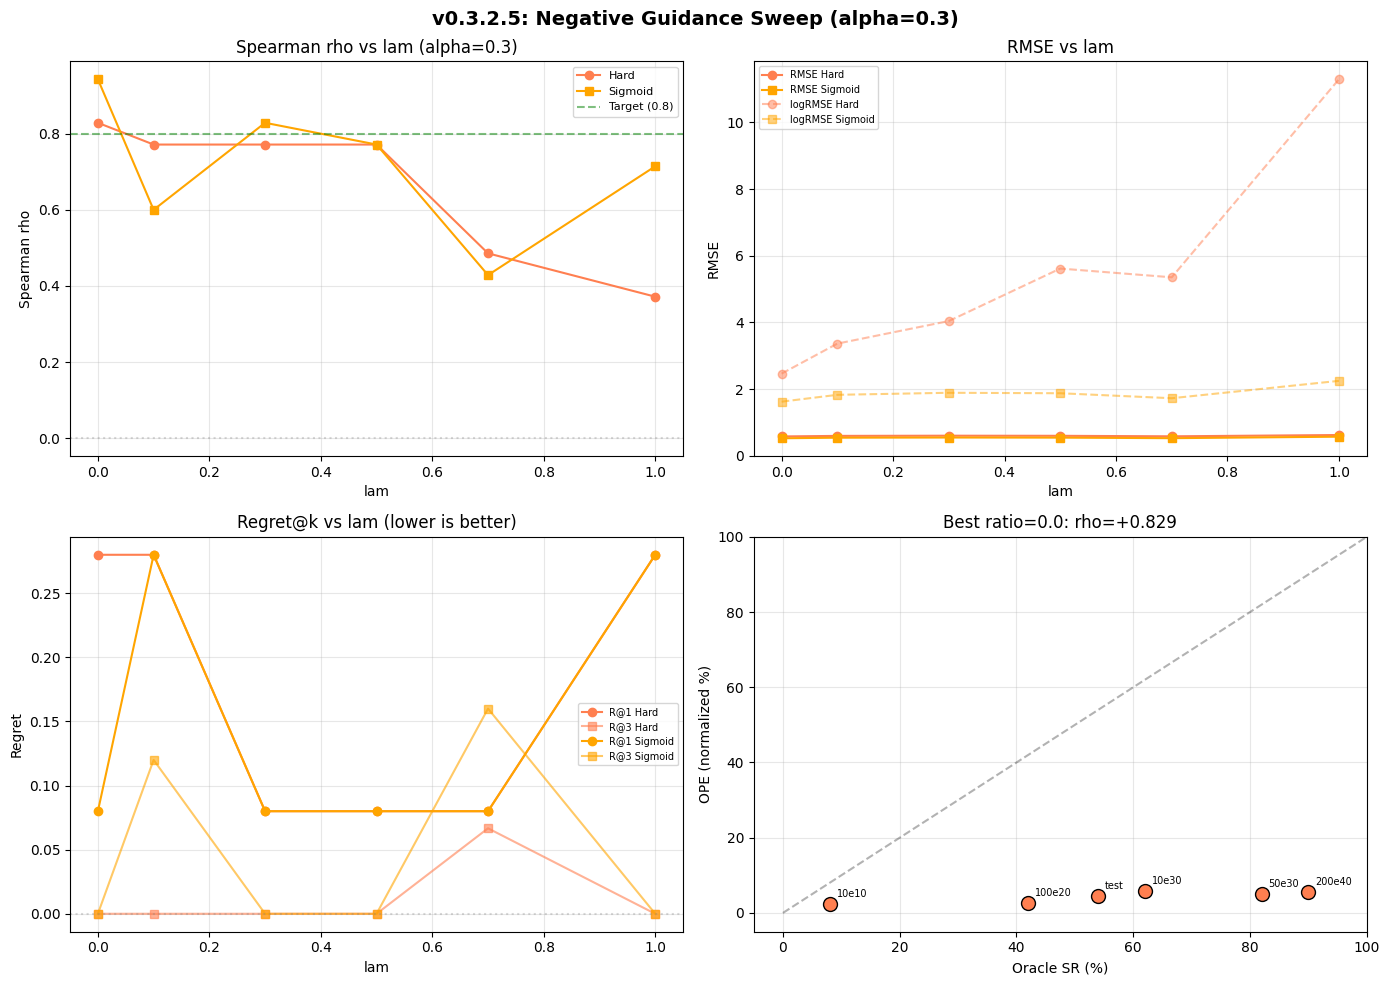

In [13]:
# ── Figure 1: Metrics vs lam ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ratios = LAMBDAS

# Panel 1: Spearman rho
ax = axes[0, 0]
ax.plot(ratios, [scale_metrics[r]["rho_hard"] for r in ratios], "o-", color="coral", label="Hard")
ax.plot(ratios, [scale_metrics[r]["rho_sigm"] for r in ratios], "s-", color="orange", label="Sigmoid")
ax.axhline(0.8, color="green", ls="--", alpha=0.5, label="Target (0.8)")
ax.axhline(0, color="gray", ls=":", alpha=0.3)
ax.set_xlabel("lam")
ax.set_ylabel("Spearman rho")
ax.set_title(f"Spearman rho vs lam (alpha={ALPHA})")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: RMSE
ax = axes[0, 1]
ax.plot(ratios, [scale_metrics[r]["rmse_hard"] for r in ratios], "o-", color="coral", label="RMSE Hard")
ax.plot(ratios, [scale_metrics[r]["rmse_sigm"] for r in ratios], "s-", color="orange", label="RMSE Sigmoid")
ax.plot(ratios, [scale_metrics[r]["log_rmse_hard"] for r in ratios], "o--", color="coral", alpha=0.5, label="logRMSE Hard")
ax.plot(ratios, [scale_metrics[r]["log_rmse_sigm"] for r in ratios], "s--", color="orange", alpha=0.5, label="logRMSE Sigmoid")
ax.set_xlabel("lam")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs lam")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Panel 3: Regret@1 and @3
ax = axes[1, 0]
ax.plot(ratios, [scale_metrics[r]["regret1_hard"] for r in ratios], "o-", color="coral", label="R@1 Hard")
ax.plot(ratios, [scale_metrics[r]["regret3_hard"] for r in ratios], "s-", color="coral", alpha=0.6, label="R@3 Hard")
ax.plot(ratios, [scale_metrics[r]["regret1_sigm"] for r in ratios], "o-", color="orange", label="R@1 Sigmoid")
ax.plot(ratios, [scale_metrics[r]["regret3_sigm"] for r in ratios], "s-", color="orange", alpha=0.6, label="R@3 Sigmoid")
ax.axhline(0, color="gray", ls=":", alpha=0.3)
ax.set_xlabel("lam")
ax.set_ylabel("Regret")
ax.set_title("Regret@k vs lam (lower is better)")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Panel 4: OPE scatter at best ratio
ax = axes[1, 1]
best = best_ratio
opes_best = np.array([sweep_results[(best, n)]["ope_hard"] / T_GEN for n in policy_names])
ax.scatter(oracle_srs * 100, opes_best * 100, s=100, c="coral", edgecolor="black", zorder=5)
for j, n in enumerate(policy_names):
    label = n.replace("demos_epoch", "e").replace("test_checkpoint", "test")
    ax.annotate(label, (oracle_srs[j]*100, opes_best[j]*100),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
ax.plot([0, 100], [0, 100], "k--", alpha=0.3)
ax.set_xlabel("Oracle SR (%)")
ax.set_ylabel("OPE (normalized %)")
ax.set_title(f"Best ratio={best}: rho={scale_metrics[best]['rho_hard']:+.3f}")
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 100)
ax.set_ylim(-5, 100)

fig.suptitle(f"v0.3.2.5: Negative Guidance Sweep (alpha={ALPHA})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

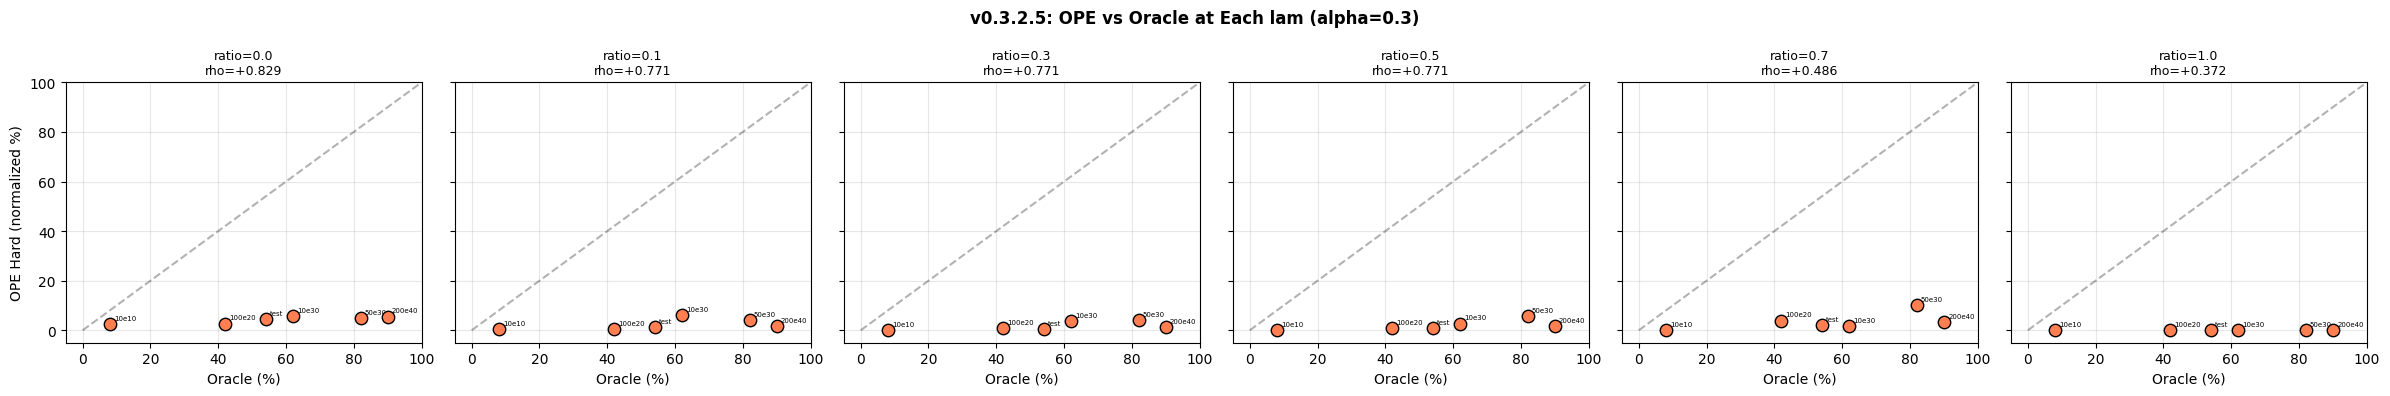

In [14]:
# ── Figure 2: OPE scatter at each lam ──
fig, axes = plt.subplots(1, len(LAMBDAS), figsize=(4*len(LAMBDAS), 4), sharey=True)

for ax, lam in zip(axes, LAMBDAS):
    opes = np.array([sweep_results[(lam, n)]["ope_hard"] / T_GEN for n in policy_names])
    m = scale_metrics[lam]
    ax.scatter(oracle_srs * 100, opes * 100, s=80, c="coral", edgecolor="black", zorder=5)
    ax.plot([0, 100], [0, 100], "k--", alpha=0.3)
    for j, n in enumerate(policy_names):
        label = n.replace("demos_epoch", "e").replace("test_checkpoint", "test")
        ax.annotate(label, (oracle_srs[j]*100, opes[j]*100),
                    textcoords="offset points", xytext=(3, 3), fontsize=5)
    ax.set_xlabel("Oracle (%)")
    ax.set_title(f"ratio={lam}\nrho={m['rho_hard']:+.3f}", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 100)
    ax.set_ylim(-5, 100)

axes[0].set_ylabel("OPE Hard (normalized %)")
fig.suptitle(f"v0.3.2.5: OPE vs Oracle at Each lam (alpha={ALPHA})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

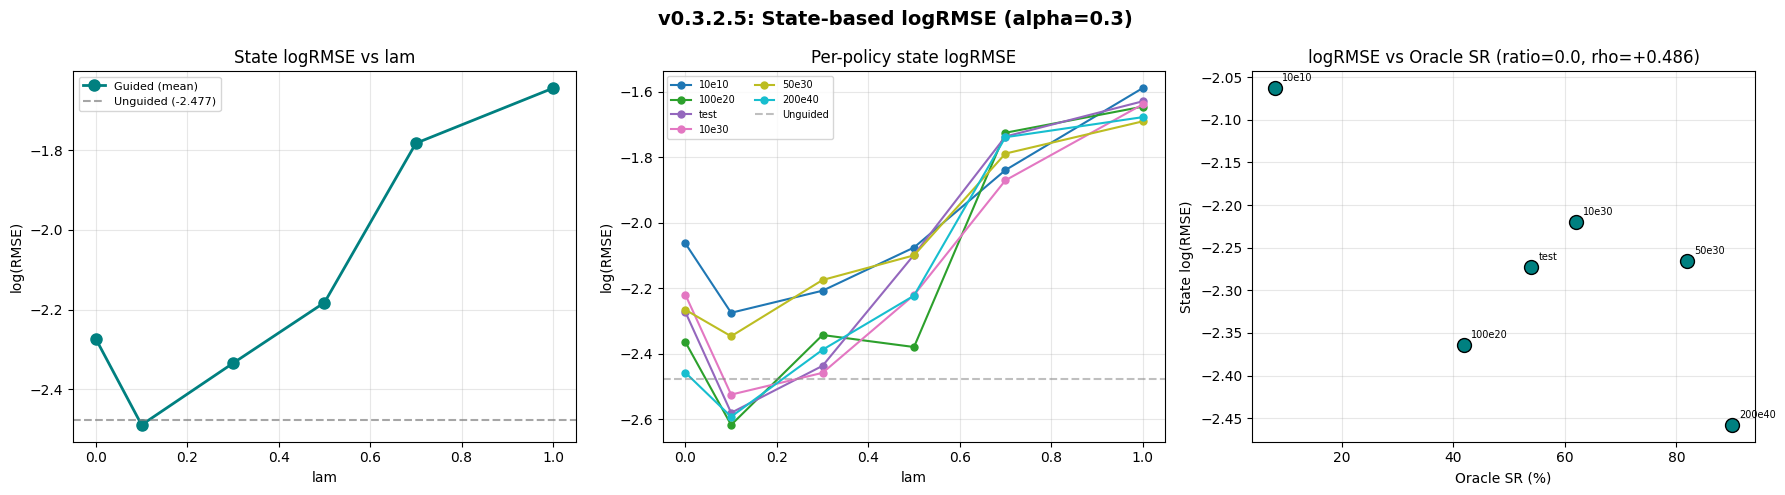

In [15]:
# ── Figure 3: State-based logRMSE ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ratios = LAMBDAS

# Panel 1: Mean state logRMSE vs lam
ax = axes[0]
mean_lrs = [scale_metrics[r]["mean_state_log_rmse"] for r in ratios]
ax.plot(ratios, mean_lrs, "o-", color="teal", linewidth=2, markersize=8, label="Guided (mean)")
ax.axhline(unguided_state_log_rmse, color="gray", ls="--", alpha=0.7, label=f"Unguided ({unguided_state_log_rmse:.3f})")
ax.set_xlabel("lam")
ax.set_ylabel("log(RMSE)")
ax.set_title("State logRMSE vs lam")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Per-policy state logRMSE across ratios
ax = axes[1]
colors_pol = plt.cm.tab10(np.linspace(0, 1, len(policy_names)))
for j, name in enumerate(policy_names):
    lrs = [sweep_results[(r, name)]["state_log_rmse"] for r in ratios]
    short = name.replace("demos_epoch", "e").replace("test_checkpoint", "test")
    ax.plot(ratios, lrs, "o-", color=colors_pol[j], label=short, markersize=5)
ax.axhline(unguided_state_log_rmse, color="gray", ls="--", alpha=0.5, label="Unguided")
ax.set_xlabel("lam")
ax.set_ylabel("log(RMSE)")
ax.set_title("Per-policy state logRMSE")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Panel 3: State logRMSE vs oracle SR at best ratio
ax = axes[2]
best = max(LAMBDAS, key=lambda r: scale_metrics[r]["rho_hard"])
lrs_best = np.array([sweep_results[(best, n)]["state_log_rmse"] for n in policy_names])
ax.scatter(oracle_srs * 100, lrs_best, s=100, c="teal", edgecolor="black", zorder=5)
for j, n in enumerate(policy_names):
    short = n.replace("demos_epoch", "e").replace("test_checkpoint", "test")
    ax.annotate(short, (oracle_srs[j]*100, lrs_best[j]),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
rho_lr, _ = stats.spearmanr(oracle_srs, -lrs_best)
ax.set_xlabel("Oracle SR (%)")
ax.set_ylabel("State log(RMSE)")
ax.set_title(f"logRMSE vs Oracle SR (ratio={best}, rho={rho_lr:+.3f})")
ax.grid(True, alpha=0.3)

fig.suptitle(f"v0.3.2.5: State-based logRMSE (alpha={ALPHA})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()